In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
# Create geometry acceptance table
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]

def lor_to_sinogram_coords(x1, y1, x2, y2):
    # Vectorized for batches, but remains compatible with scalars
    dx = x2 - x1
    dy = y2 - y1
    nx = -dy
    ny = dx
    norm = np.hypot(nx, ny)
    nx = nx / norm
    ny = ny / norm
    return x1 * nx + y1 * ny

def get_geomask(sourcex, sourcey):
    x1y1 = map[3072:6144, :2] - np.array([sourcex, sourcey])
    x2y2 = map[0:3072, :2]   - np.array([sourcex, sourcey])
    x1 = x1y1[:, 0][:, None]  # shape (3072, 1)
    y1 = x1y1[:, 1][:, None]
    x2 = x2y2[:, 0][None, :]  # shape (1, 3072)
    y2 = x2y2[:, 1][None, :]
    dx = x2 - x1
    dy = y2 - y1
    nx = -dy
    ny = dx
    norm = np.hypot(nx, ny)
    nx = nx / norm
    ny = ny / norm
    s = x1 * nx + y1 * ny
    table = np.abs(s) < 20
    return np.asarray(table, dtype = np.bool)

boundangles = np.array([-1.12011132679, -2.02148132679, -4.26170398, -5.16307398])
boundangles = -boundangles
def sourceposlist(npos, r = 137):
    sourceposlist = []
    for n in range(npos):
        theta = boundangles[0] / (npos / 4) * n
        if n >= npos / 4:
            theta += boundangles[1] - boundangles[0]
        if n >= 3*npos / 4:
            theta += boundangles[1] - boundangles[0]
        sourceposlist.append((np.cos(theta) * r, -np.sin(theta) * r))
    return sourceposlist


In [41]:
print(sourceposlist(30))
n = 10
geomask = get_geomask(sourceposlist(30)[n][0], sourceposlist(30)[n][1])
print(sourceposlist(30)[n])
if os.path.exists(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/geomask{n}.bin'):
    os.remove(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/geomask{n}.bin')
with open(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/geomask{n}.bin', 'ab') as f:
    geomask.tofile(f)

[(np.float64(137.0), np.float64(-0.0)), (np.float64(135.47495368923208), np.float64(-20.38472278203522)), (np.float64(130.93376754889889), np.float64(-40.31561131188402)), (np.float64(123.47754404863296), np.float64(-59.34893525344753)), (np.float64(113.2722844459721), np.float64(-77.06094715477346)), (np.float64(100.54519302569688), np.float64(-93.05731652817718)), (np.float64(85.57961874864368), np.float64(-106.98190900725595)), (np.float64(68.70874692634169), np.float64(-118.52471512647449)), (np.float64(-68.70874692518093), np.float64(-118.52471512714739)), (np.float64(-85.57961874759602), np.float64(-106.98190900809404)), (np.float64(-100.5451930247855), np.float64(-93.05731652916187)), (np.float64(-113.27228444521744), np.float64(-77.06094715588273)), (np.float64(-123.47754404805175), np.float64(-59.34893525465675)), (np.float64(-130.93376754850408), np.float64(-40.315611313166265)), (np.float64(-135.47495368903245), np.float64(-20.384722783361948)), (np.float64(-137.0), np.float

In [36]:
name = 'hcirc_pcut'
path = f'/home/kale-chen/Documents/PET/MDA_03162026/Data/{name}.dat'
outputpath = f'/home/kale-chen/Documents/PET/MDA_03162026/Data/{name}_geomasked.bin'
npos, duration = 30, 900
sourcepositions = sourceposlist(npos)
time0 = 0
if os.path.exists(outputpath):
    os.remove(outputpath)
totalevents = 0
with open(outputpath, 'ab') as f:
    for n in range(npos):
        timewindow = (n * duration / npos, (n+1) * duration / npos)
        getgeomask = get_geomask(sourcepositions[n][0], sourcepositions[n][1])
        with open(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/geomask{n}.bin', 'ab') as g:
            getgeomask.tofile(g)
        neventsthispos, neventsthisposcut = 0, 0
        for chunk in tqdm(pd.read_csv(path, sep = '\t', chunksize = 1000000, usecols = [2, 4, 7, 9], header = None)):
            if time0 == 0:
                time0 = chunk.iloc[0, 0]
                print(time0)
            chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
            timemask = ((chunk['TimeL'] - time0) // 1e12 >= timewindow[0]) & ((chunk['TimeL'] - time0) // 1e12 < timewindow[1])
            chunk = chunk[timemask]
            neventsthispos += len(chunk)
            if len(chunk) == 0:
                continue
            chunk = np.asarray(chunk)
            chunk[:, 1] = (chunk[:, 1] - 131072) % 3072
            chunk[:, 3] = chunk[:, 3] % 3072
            geommask = getgeomask[chunk[:, 1], chunk[:, 3]]
            chunk = chunk[geommask]
            chunk.tofile(f)
            #print(chunk)
            neventsthisposcut += len(chunk)
            totalevents += len(chunk)
        print(timewindow, neventsthispos, neventsthisposcut)
print(totalevents)

1it [00:00,  3.57it/s]

10076549289416


62it [00:15,  3.93it/s]


(0.0, 30.0) 2049382 419834


62it [00:15,  3.96it/s]


...

(810.0, 840.0) 2069364 471432


62it [00:14,  4.37it/s]


(840.0, 870.0) 2021793 455121


62it [00:14,  4.36it/s]

(870.0, 900.0) 2000439 441799
12867090


19849652
15846 11724
19794702
19822084


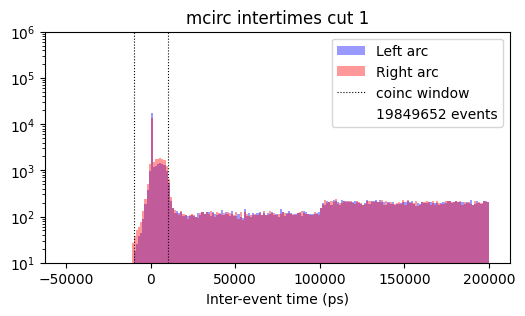

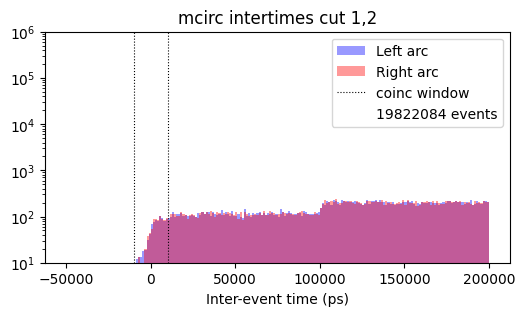

In [16]:
print(len(intertimes))
print(len(intertimes[intertimes[:, 0] == 0]), len(intertimes[intertimes[:, 1] == 0]))
mask = (intertimes[:, 0] == 0) | (intertimes[:, 1] == 0)
realmask = np.zeros((len(intertimes) +1 ), dtype = np.bool)
realmask[0:-1] = mask
realmask[1:] = realmask[1:] | mask
realmask = ~realmask
print(np.sum(realmask))
if os.path.exists(f'{path.replace(".dat", "_itimemask.bin")}'):
    os.remove(f'{path.replace(".dat", "_itimemask.bin")}')
with open(f'{path.replace(".dat", "_itimemask.bin")}', 'ab') as f:
    realmask.tofile(f)
intertimescut = intertimes[intertimes[:, 0] != 0]
intertimescut = intertimescut[intertimescut[:, 1] != 0]
#intertimes = np.abs(intertimes)
#intertimescut = np.abs(intertimescut)
print(len(intertimescut))


ylim = (1e1, 1e6)
#plotrange = (-100000, 4000000)
plotrange = (-50000, 200000)
def pltextras(nevents, title = f'{name} intertimes'):
    plt.yscale('log')
    plt.ylim(*ylim)
    plt.title(title)
    plt.xlabel('Inter-event time (ps)')
    plt.vlines([-10000, 10000], *ylim, color = 'black', linestyle = 'dotted', linewidth = 0.8, label = 'coinc window')
    #plt.vlines([100000], *ylim, color = 'red', linestyle = 'dotted', linewidth = 0.8, label = '100000 ps')
    plt.plot([0, 0], [0, 0], linewidth = 0, label = f'{nevents} events')
    plt.legend(loc = 'upper right')
plt.figure(0, figsize = (6, 3))
plt.hist(intertimes[:, 0], bins = 200, range = plotrange, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.hist(intertimes[:, 1], bins = 200, range = plotrange, color = 'red', alpha = 0.4, label = 'Right arc')
pltextras(len(intertimes), f'{name} intertimes cut 1')
plt.savefig(f'plots/{name}_intertimes_cut1.png')
plt.figure(1, figsize = (6, 3))
plt.hist(intertimescut[:, 0], bins = 200, range = plotrange, color = 'blue', alpha = 0.4, label = 'Left arc')
plt.hist(intertimescut[:, 1], bins = 200, range = plotrange, color = 'red', alpha = 0.4, label = 'Right arc')
pltextras(len(intertimescut), f'{name} intertimes cut 1,2')
plt.savefig(f'plots/{name}_intertimes_cut12.png')
plt.show()

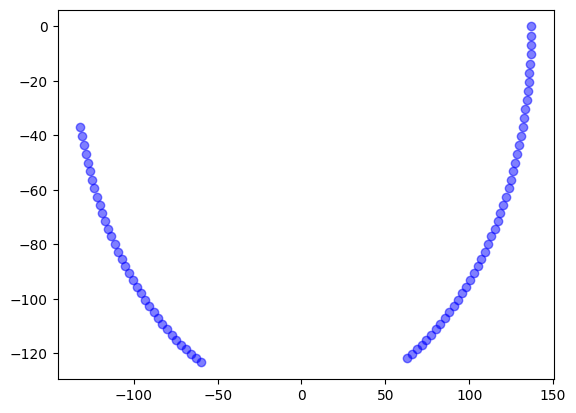

In [28]:
sourcepositions = sourceposlist(npos)
for source in sourcepositions[0:80]:
    plt.scatter(source[0], source[1], color = 'blue', alpha = 0.5)
plt.show()